In [71]:
import os
import random
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import recall_score, roc_auc_score, f1_score, precision_score, classification_report, confusion_matrix, accuracy_score
from sklearn.inspection import permutation_importance

import lightgbm as lgb
import shap

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

Загрузка и предобработка данных. Все примерно как в ноутбуке с бейзлайном. Загружаю данные, удаляю лишние столбцы, делю на train и test, разделяю на категориальные и численные данные. Для них соответственно делаю препроцессоры:
- Для численных: пропущенные значения по медиане и нормализация (прим.: Несмотря на то что деревья не чувствительны к масштабу, масштабирование важно, потому что модель проходит через `GridSearchCV` и некоторые параметры могут зависеть от масштаба)
- Для категориальных: пропущенные значения заменяются на самые частые и one-hot кодирование

LGBM хорошо работает с категориальными данными, но для использования в `GridSearchCV` требуется явно закодировать категориальные значения

In [56]:
df = pd.read_csv('conversion_predictors_of_clinically_isolated_syndrome_to_multiple_sclerosis.csv')
df = df.drop(columns=['Unnamed: 0', 'Initial_EDSS', 'Final_EDSS'])
df.columns = df.columns.str.lower()
df['group'] = df['group'].replace({2: 0, 1: 1})

In [57]:
target = 'group' #таргетная переменная
X = df.drop(columns=[target])
y = df[target].astype(int) #вынесли в отдельную таблицу
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
) #разделение на трейн и тест
print(f"Размеры выборок: train={X_train.shape}, test={X_test.shape}")
print("Баланс (train):\n", y_train.value_counts(normalize=True))

Размеры выборок: train=(218, 16), test=(55, 16)
Баланс (train):
 group
0    0.541284
1    0.458716
Name: proportion, dtype: float64


In [58]:
num_features = ['age', 'schooling']
cat_features = [c for c in X.columns if c not in num_features]

In [59]:
print("Числовые:", num_features)
print("Категориальные:", cat_features)

Числовые: ['age', 'schooling']
Категориальные: ['gender', 'breastfeeding', 'varicella', 'initial_symptom', 'mono_or_polysymptomatic', 'oligoclonal_bands', 'llssep', 'ulssep', 'vep', 'baep', 'periventricular_mri', 'cortical_mri', 'infratentorial_mri', 'spinal_cord_mri']


In [60]:
num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
                         ('scaler', StandardScaler())])
cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [61]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
], remainder='drop', sparse_threshold=0)

In [62]:
preprocessor.fit(X_train)
X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)

In [63]:
ohe = preprocessor.named_transformers_['cat'].named_steps['ohe']
cat_feature_names = list(ohe.get_feature_names_out(cat_features))
feature_names = num_features + cat_feature_names
len(feature_names), feature_names

(47,
 ['age',
  'schooling',
  'gender_1.0',
  'gender_2.0',
  'breastfeeding_1.0',
  'breastfeeding_2.0',
  'breastfeeding_3.0',
  'varicella_1.0',
  'varicella_2.0',
  'varicella_3.0',
  'initial_symptom_1.0',
  'initial_symptom_2.0',
  'initial_symptom_3.0',
  'initial_symptom_4.0',
  'initial_symptom_5.0',
  'initial_symptom_6.0',
  'initial_symptom_7.0',
  'initial_symptom_8.0',
  'initial_symptom_9.0',
  'initial_symptom_10.0',
  'initial_symptom_11.0',
  'initial_symptom_12.0',
  'initial_symptom_13.0',
  'initial_symptom_14.0',
  'initial_symptom_15.0',
  'mono_or_polysymptomatic_1.0',
  'mono_or_polysymptomatic_2.0',
  'mono_or_polysymptomatic_3.0',
  'oligoclonal_bands_0.0',
  'oligoclonal_bands_1.0',
  'oligoclonal_bands_2.0',
  'llssep_0.0',
  'llssep_1.0',
  'ulssep_0.0',
  'ulssep_1.0',
  'vep_0.0',
  'vep_1.0',
  'baep_0.0',
  'baep_1.0',
  'periventricular_mri_0.0',
  'periventricular_mri_1.0',
  'cortical_mri_0.0',
  'cortical_mri_1.0',
  'infratentorial_mri_0.0',
  'i

Получается 47 фичей при условии, что все категориальные разбиты на бинарные векторы.

## Модель
`LightGBM` выбран как основной алгоритм по нескольким причинам:

- устойчив к нелинейным зависимостям, характерным для медицинских данных;
- хорошо работает на небольших датасетах;
- быстро обучается;
- обладает механизмами борьбы с дисбалансом классов;
- предоставляет информативные меры важности признаков и совместим с SHAP.

## Подбор гиперпараметров

Для улучшения прогностической способности модели использую `GridSearchCV`
Оптимизируются следующие параметры:

- `n_estimators` — число деревьев, влияет на баланс переобучения/недообучения
- `max_depth` — ограничение глубины деревьев
- `num_leaves` — максимальное число листьев в дереве
- `learning_rate` — скорость обучения, малые значения обеспечивают стабильность
- `min_child_samples` — минимальное число наблюдений в листе, помогает бороться с переобучением
- `subsample` и `colsample_bytree` — параметры стохастичности деревьев, уменьшают дисперсию модели
- `reg_alpha` - L1-регуляризация, борьба с переобучением
- `reg_lambda` - L2-регуляризация, сглаживает веса, уменьшает разброс между фолдами

Поисковое пространство параметров подобрано, чтобы охватить
как более простые модели, так и более сложные - но без раздувания сетки

In [64]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

lgb_est = lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [16, 31, 64],
    'max_depth': [3, 5, 10, 20],
    'min_child_samples': [5, 10, 20],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.4, 0.6, 0.8],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [0, 0.1, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rs = RandomizedSearchCV(lgb_est, param_distributions=param_dist, n_iter=30,
                        scoring='recall', cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=1)

#тюнинг на уже трансформированных данных
rs.fit(X_train_t, y_train)

print("Лучшее среднее recall:", rs.best_score_)
print("Лучшие параметры:", rs.best_params_)

best_model = rs.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Info] Number of positive: 100, number of negative: 118
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000363 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 132
[LightGBM] [Info] Number of data points in the train set: 218, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.458716 -> initscore=-0.165514
[LightGBM] [Info] Start training from score -0.165514
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

## Обучение модели и измерение качества на тестовой выборки


Критерием оптимальности выступает `recall`, так как задача требует максимизировать
выявление пациентов, потенциально развивающих РС. FN-кейсы критически опасны, `recall` - приоритетная метрика

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=3,
               min_child_samples=5, n_estimators=500, n_jobs=-1, num_leaves=16,
               random_state=42, reg_alpha=1.0, reg_lambda=0.1, subsample=0.6)

,0
recall,0.960000
accuracy,0.909091
precision,0.857143
f1,0.905660
roc_auc,0.962667


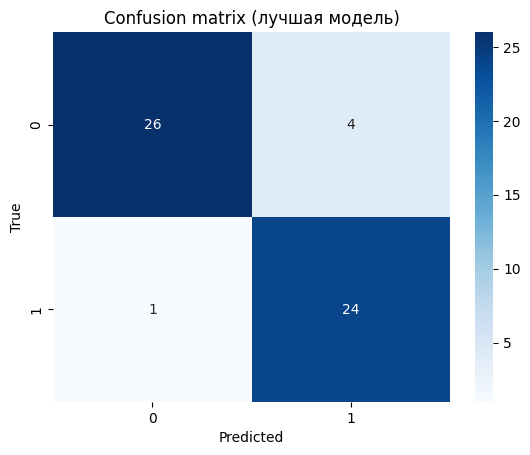

In [75]:
display(best_model)
y_pred = best_model.predict(X_test_t)
y_proba = best_model.predict_proba(X_test_t)[:,1]

metrics_test = {
    "recall": recall_score(y_test, y_pred),
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}
display(pd.Series(metrics_test))


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (лучшая модель)")
plt.show()


`recall = 0,96`, отличный показатель, на 0,1 в среднем выше бейзлайна. Остальные показатели тоже неплохие. Особенно радует всего один FN, которые для задачи критичны

## Глобальная интерпретация

Использую permutation importance и SHAP:

- выявление ключевых клинических предикторов
- направление их влияния


,feature,importance_mean,importance_std
0,schooling,0.140000,0.049261
1,oligoclonal_bands_1.0,0.073333,0.043919
2,periventricular_mri_0.0,0.066667,0.048808
3,age,0.044000,0.033226
4,varicella_3.0,0.032000,0.029933
5,mono_or_polysymptomatic_1.0,0.029333,0.017689
6,breastfeeding_3.0,0.026667,0.027968
7,initial_symptom_1.0,0.025333,0.021868
8,gender_1.0,0.024000,0.019596
9,infratentorial_mri_0.0,0.024000,0.019596


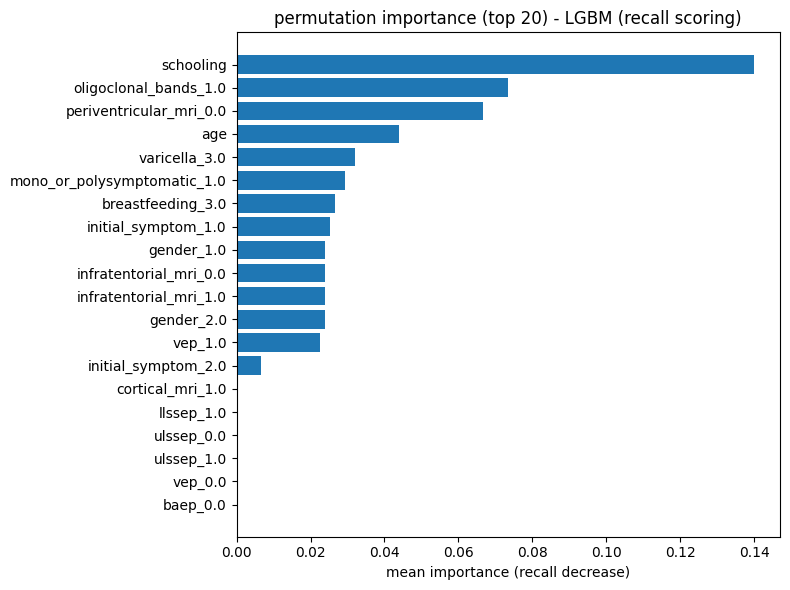

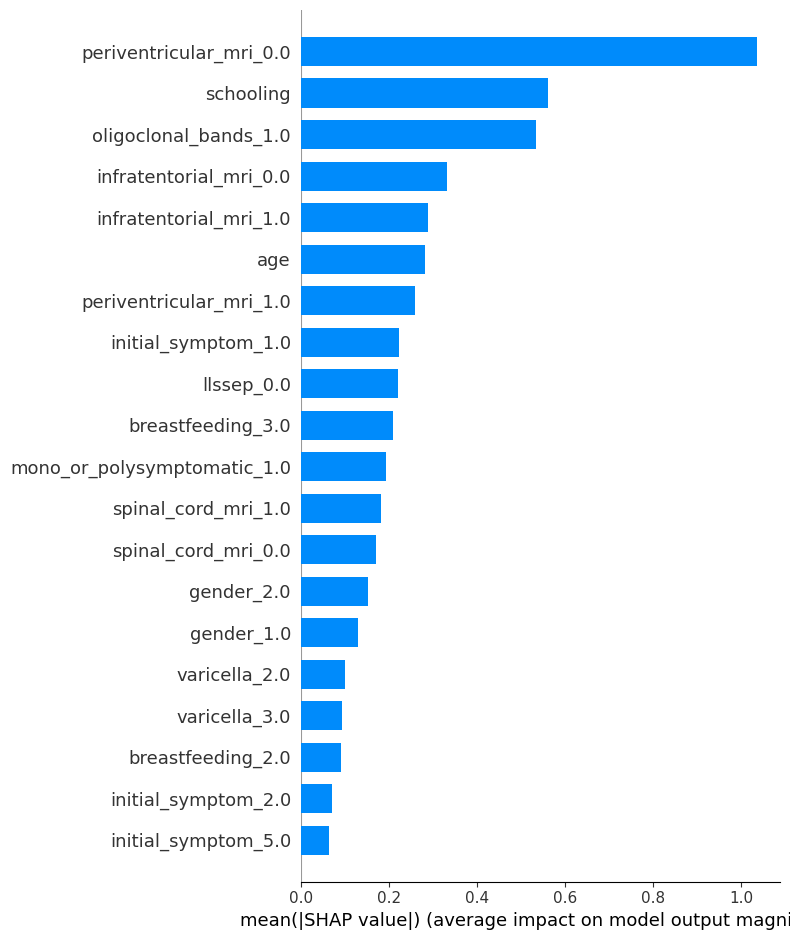

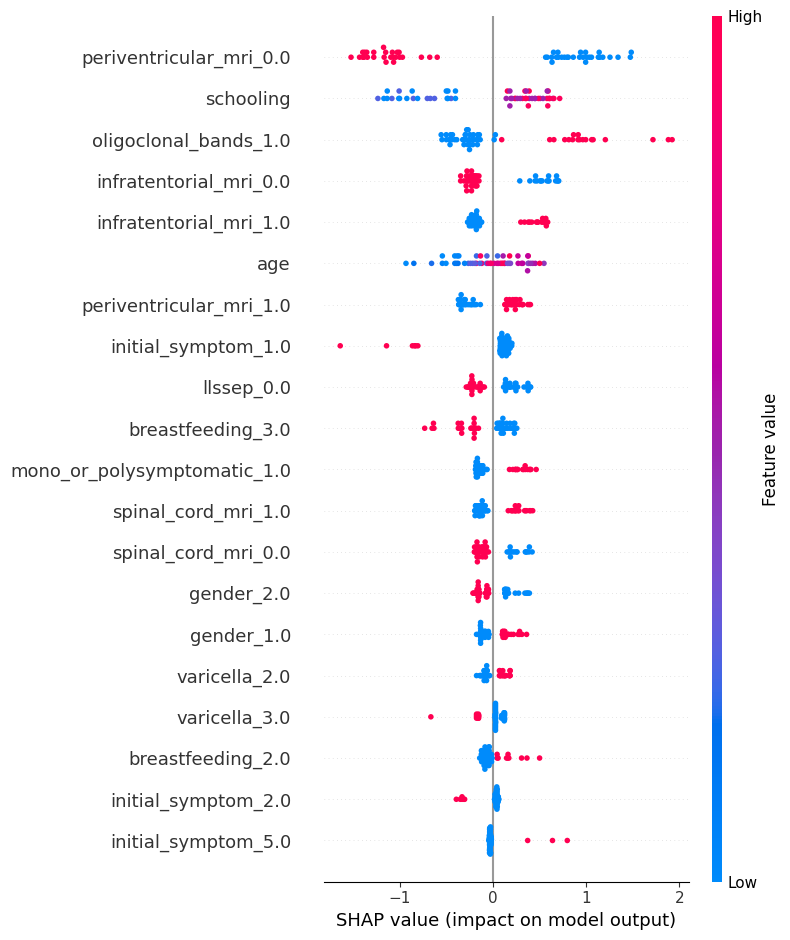

In [76]:
#permutation importance (scoring по recall)
perm = permutation_importance(best_model, X_test_t, y_test, n_repeats=30, random_state=RANDOM_STATE, scoring='recall', n_jobs=-1)
perm_idx = perm.importances_mean.argsort()[::-1]

imp_df = pd.DataFrame({
    'feature': [feature_names[i] for i in perm_idx],
    'importance_mean': perm.importances_mean[perm_idx],
    'importance_std': perm.importances_std[perm_idx]
}).head(20)

display(imp_df)

#график
plt.figure(figsize=(8,6))
plt.barh(imp_df['feature'][::-1], imp_df['importance_mean'][::-1])
plt.xlabel('mean importance (recall decrease)')
plt.title('permutation importance (top 20) - LGBM (recall scoring)')
plt.tight_layout()
plt.show()

#SHAP (TreeExplainer)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_t)

#global summary (bar)
shap.summary_plot(shap_values, X_test_t, feature_names=feature_names, plot_type='bar', show=True)

#beeswarm (detailed global)
shap.summary_plot(shap_values, X_test_t, feature_names=feature_names, show=True)

# Permutation importance

Влияние признака на `recall`. Насколько сильно падает показатель, если "сломать" признак

- Самый сильный предиктор - образование (`schooling`). Странно, но может быть следствием социально-экономического статуса, образованные пациенты чаще обращаются к врачам
- Далее - oligoclonal_bands_1.0 (наличие олигоклональных полос),
periventricular_mri_0.0 (отсутствие перивентрикулярных поражений) - наличие олигоклональных полос является установленным биомаркером активного иммунного ответа в ЦНС, а перивентрикулярные очаги на МРТ часто используются для стратификации риска. Их высокие значения importance подтверждают, что модель использует именно те признаки, которые ожидаемо коррелируют с патологическим процессом
- age, mono_or_polysymptomatic_1.0, initial_symptom_1.0 - возраст может быть связан с вероятностью определённых исходов, а характер дебюта - отражать тяжесть первого эпизода и, соответственно, риск дальнейшего развития заболевания, более того initial_symptom = 1 - нарушения зрения, через которые довольно часто дебютирует РС

Модель использует не только клинические, но и социально-демографические данные. Выделяются те, которые присутствуют в критериях Макдональда (https://en.wikipedia.org/wiki/McDonald_criteria)



## SHAP

- Periventricular_MRI_0.0 - cамый значимый фактор. Отсутствие перивентрикулярных очагов сильно снижает вероятность конверсии. Это соответствует диагностическим критериям РС, где такие очаги — один из ключевых признаков
- Schooling - снова социально-демографический фактор
- Oligoclonal_Bands_1.0 - наличие олигоклональных полос - мощный положительный предиктор, увеличивающий вероятность перехода симптомов в заболевание
- Infratentorial_MRI (0/1), age - наличие инфратенториальных очагов увеличивает риск; отсутствие снижает. Возраст оказывает умеренное влияние
- Periventricular_MRI_1.0 - наличие перивентрикулярных очагов также увеличивает вероятность конверсии. Значимость ниже, чем у категории 0.0, что связано с распределением данных и взаимодействием с другими МРТ-признаками

Итог:
Модель формирует решение на основе сочетания МРТ-находок, биомаркеров и демографии. SHAP подтверждает клинически ожидаемую структуру признаков и демонстрирует, что оптимизация на recall приводит к усилению факторов, “подстраховывающих” модель от FN

## Локальная интерпретация, наиболее интересны именно FN


FN пациент 93 
Истинный класс: 1
Предсказанный класс: 0
Вероятность класcа 1: 0.086


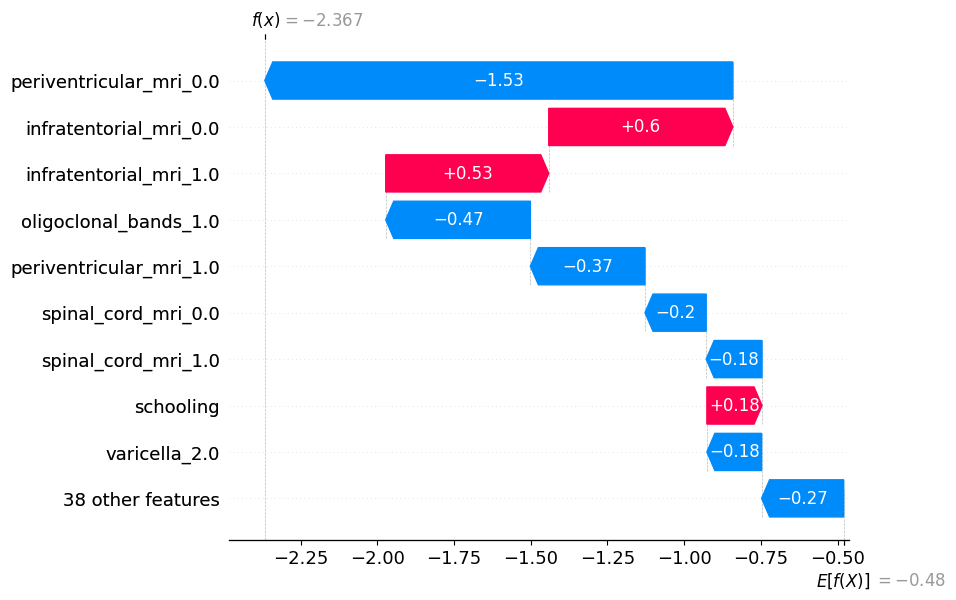

In [86]:
#предсказания
y_proba = best_model.predict_proba(X_test_t)[:, 1]
y_pred = (y_proba > 0.5).astype(int)

#FN: true 1, predicted 0
fn_mask = (y_test == 1) & (y_pred == 0)
fn_indices = X_test[fn_mask].index.tolist()

#маппинг: индекс → позиция
test_positions = {idx: pos for pos, idx in enumerate(X_test.index)}

#локальная интерпретация
for idx in fn_indices:
    pos = test_positions[idx]   #позиция в shap_values
    sv = shap_values[pos]

    print(f"\nFN пациент {idx} ")
    print(f"Истинный класс: {y_test.loc[idx]}")
    print(f"Предсказанный класс: {y_pred[test_positions[idx]]}")
    print(f"Вероятность класcа 1: {y_proba[test_positions[idx]]:.3f}")

    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value,
        sv,
        feature_names=feature_names
    )


Наибольшие факторы, толкнувшие модель к ошибочному классу:

`periventricular_mri_0.0 (–1.53)`
Отрицательная МРТ-признак в перивентрикулярной области сильно уменьшает вероятность положительного исхода по логике модели

`oligoclonal_bands_1.0 (–0.47)`
Положительные олигоклональные полосы в ликворе обычно повышают риски, но в структуре one-hot модель использует конкретные категории. В данном случае именно эта кодировка уменьшила вероятность

`periventricular_mri_1.0 (–0.37)`
Еще один MRI-признак, также работающий против положительной классификации

`spinal_cord_mri_0.0 (–0.20)` и `spinal_cord_mri_1.0 (–0.18)`
Спинальные признаки также внесли отрицательный вклад, смещая предсказание от события

Модель решила, что у пациента слишком много признаков, характерных для низкого риска, особенно доминирующий `periventricular_mri_0.0`. Эти признаки сильнее, чем те, что указывали на риск события

Локальная интерпретация пациента #11


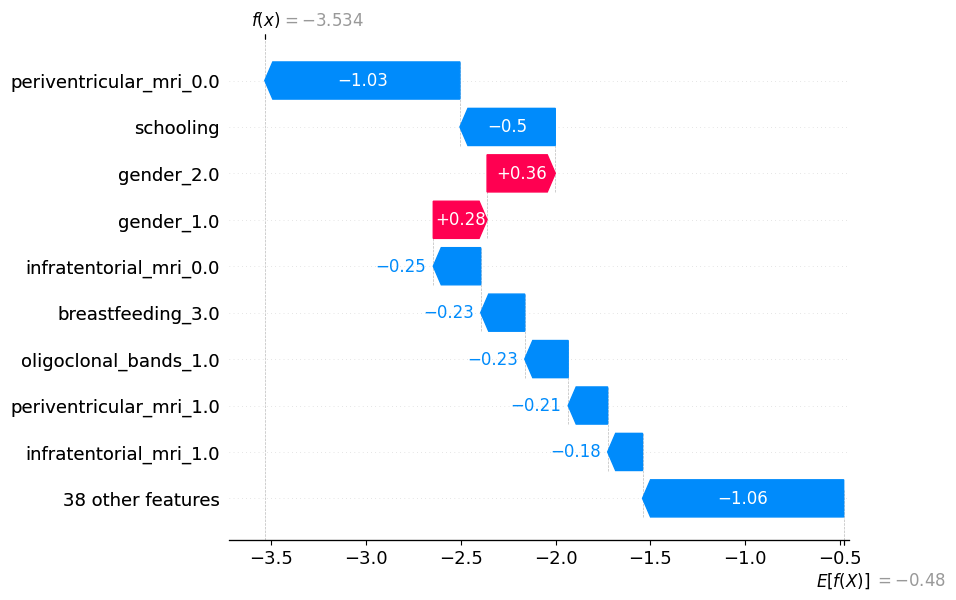


Истинный класс: 0
Предсказанный класс: 0  (p=0.028)

Локальная интерпретация пациента #44


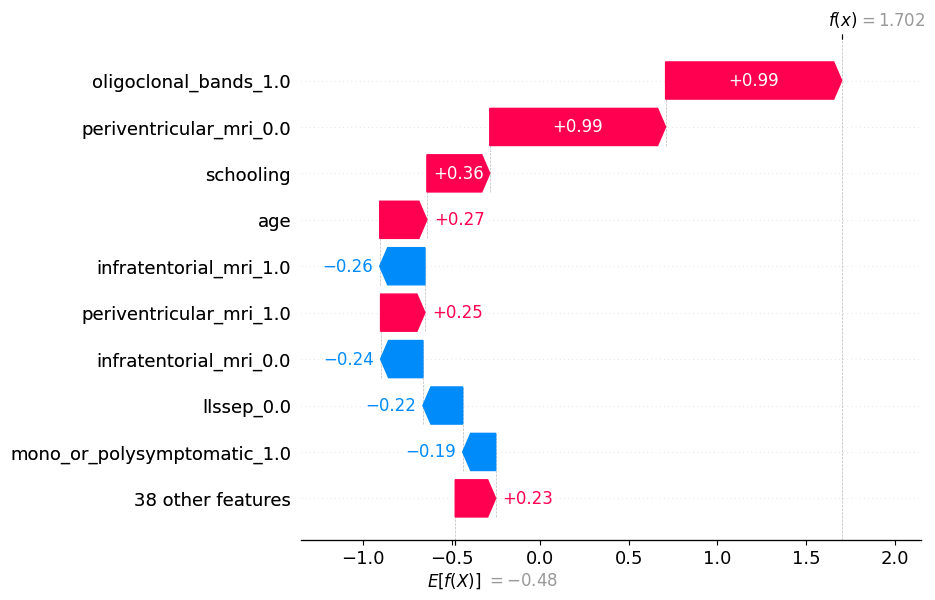


Истинный класс: 1
Предсказанный класс: 1  (p=0.846)

Локальная интерпретация пациента #42


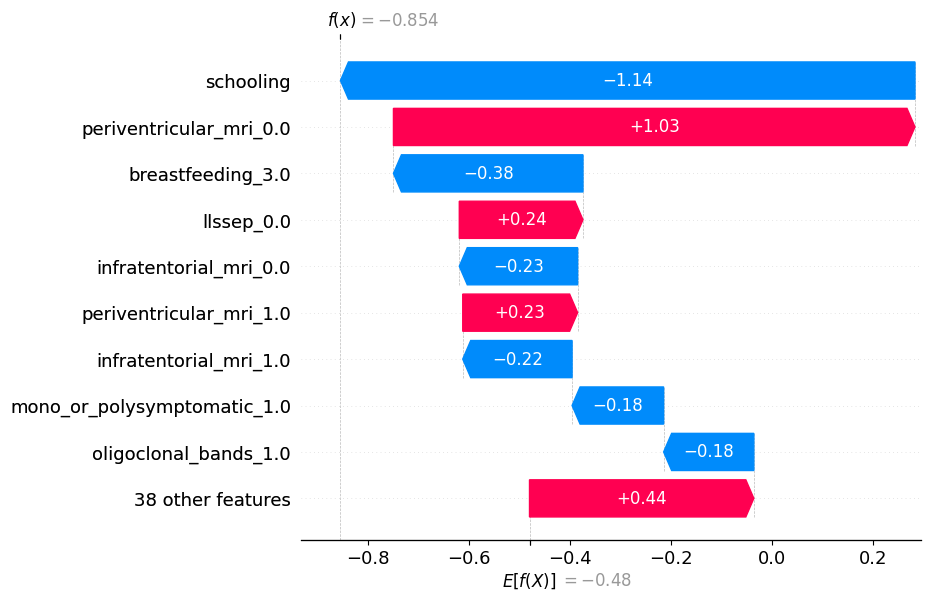


Истинный класс: 0
Предсказанный класс: 0  (p=0.299)



In [90]:
n_local_random = min(3, X_test_t.shape[0])
random_indices = np.random.choice(range(X_test_t.shape[0]), size=n_local_random, replace=False)

for idx in random_indices:
    print(f"Локальная интерпретация пациента #{idx}")

    sv = shap_values[idx]

    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value,
        sv,
        feature_names=feature_names
    )

    pred_prob = best_model.predict_proba(X_test_t[idx:idx+1])[0][1]
    pred_label = int(pred_prob >= 0.5)
    true_label = y_test.iloc[idx]

    print(f"\nИстинный класс: {true_label}")
    print(f"Предсказанный класс: {pred_label}  (p={pred_prob:.3f})\n")

